In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("../data/raw/material_forecast_dataset.csv")

df.head()


,project_budget,region,tower_type,month,year,weather_index,lead_time_days,material_name,quantity
0,7054291,Maharashtra,Distribution,6,2024,0.49,28,Power Transformer 220kV,5
1,12126106,West Bengal,Transmission,1,2025,0.55,26,High Voltage Fuse,11
2,6913971,Maharashtra,Distribution,12,2024,0.84,17,Power Transformer 220kV,7
3,5887126,Karnataka,Distribution,9,2024,0.34,15,Power Transformer 220kV,3
4,8320897,Delhi,Distribution,4,2024,0.79,17,Circuit Breaker,3


In [7]:
print("---Data shape----")
print(df.shape)
print("---Data info---")
print(df.info())
print("---Descriptive Statistics---")
print(df.describe())


---Data shape----
(100000, 9)
---Data info---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   project_budget  100000 non-null  int64  
 1   region          100000 non-null  object 
 2   tower_type      100000 non-null  object 
 3   month           100000 non-null  int64  
 4   year            100000 non-null  int64  
 5   weather_index   100000 non-null  float64
 6   lead_time_days  100000 non-null  int64  
 7   material_name   100000 non-null  object 
 8   quantity        100000 non-null  int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 6.9+ MB
None
---Descriptive Statistics---
       project_budget          month           year  weather_index  \
count    1.000000e+05  100000.000000  100000.000000  100000.000000   
mean     8.994201e+06       6.485860    2024.499430       0.600322   
std      2.308939e+06       3.448

In [ ]:
# . Quantity check
print("--- Missing Values ---")
print(df.isna().sum())

--- Missing Values ---
project_budget    0
region            0
tower_type        0
month             0
year              0
weather_index     0
lead_time_days    0
material_name     0
quantity          0
dtype: int64


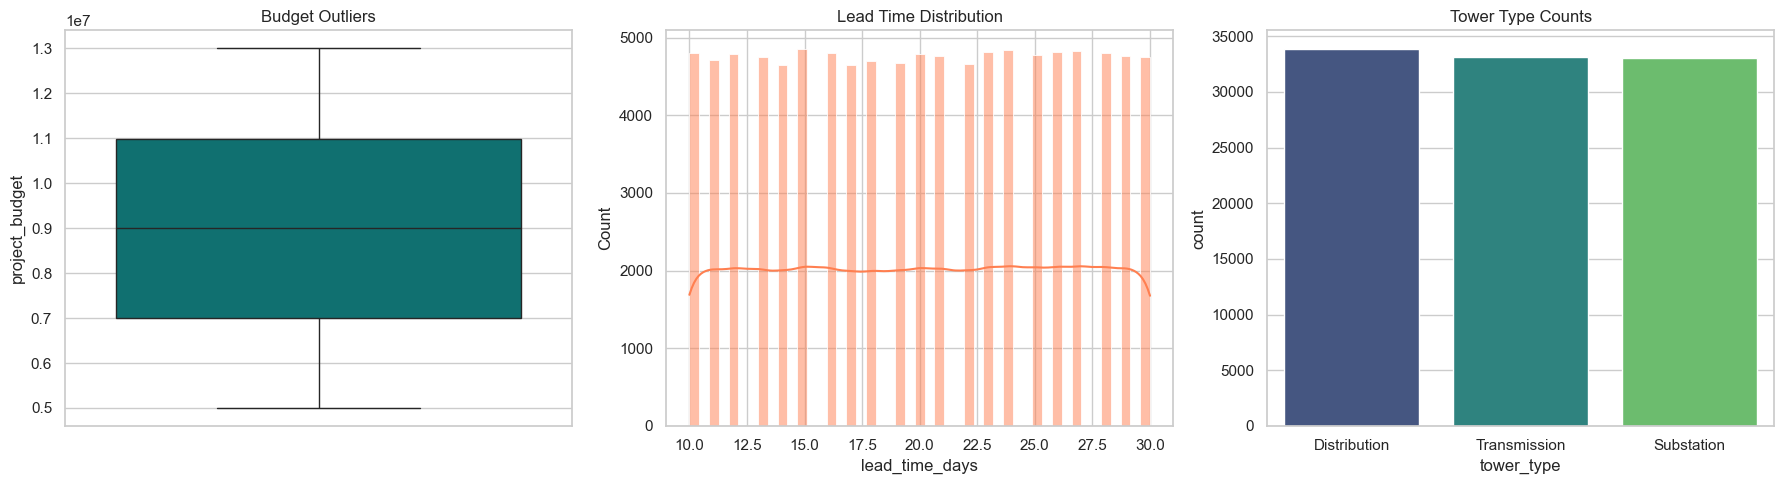

In [33]:
# 2. Distribution Check
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(y=df['project_budget'], ax=axes[0], color='teal').set_title('Budget Outliers')
sns.histplot(df['lead_time_days'], kde=True, ax=axes[1], color='coral').set_title('Lead Time Distribution')
sns.countplot(x=df['tower_type'], ax=axes[2], palette='viridis', hue=df['tower_type'], legend=False).set_title('Tower Type Counts')
plt.tight_layout()
plt.show()

In [34]:
# 3. Categorical Uniqueness (Find typos)
print("\n--- Unique Regions (Check for typos) ---")
print(df['region'].unique())


--- Unique Regions (Check for typos) ---
['Maharashtra' 'West Bengal' 'Karnataka' 'Delhi' 'Uttar Pradesh'
 'Madhya Pradesh' 'Gujarat' 'Bihar' 'Tamil Nadu' 'Rajasthan']


In [35]:
print("\n--- Unique Materials ---")
print(df['material_name'].unique())



--- Unique Materials ---
['Power Transformer 220kV' 'High Voltage Fuse' 'Circuit Breaker'
 'Insulator Disc' 'Galvanized Steel Wire' 'Relay Panel' 'ACSR Conductor'
 'Steel Tower' 'Copper Cable 400mm' 'Earthing Rod']


Simplified Analysis
Clean Data (No Errors)
    The dataset is very clean with no missing values and properly formatted categories.
    This means you don’t need much data cleaning.
Balanced Data (Fair Learning)
    All categories (like region and tower type) have almost equal data.
    The model won’t be biased toward any one category.
Random Lead Time (No Pattern Yet)
    Lead time values are evenly spread between 10–30 days.
    There is no clear “average” or common lead time.
Stable Budget Range
    Most project budgets are around 9 million, with no extreme values.
    Data represents normal projects, not unusual or risky ones.
No Strong Direct Relationships
    Features (like weather or region) don’t strongly affect outcomes on their own.
    The model won’t find easy patterns directly.
Quantity Affects Cost
    The only clear pattern is:
    More quantity → Higher project budget
Feature Engineering is Important
Since raw data has no strong patterns, you must create new features (like seasonal trends or ratios).
 This helps the model learn better and improve predictions.